In [ ]:
# Colab mein sabse pehle yeh run karo
import torch

print("="*45)
print("GPU CHECK")
print("="*45)
print(f"PyTorch version  : {torch.__version__}")
print(f"GPU available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory       : "
          f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device('cuda')
    print("\n✅ GPU ready! DistilBERT chalega!")
else:
    device = torch.device('cpu')
    print("\n⚠️ GPU nahi mila — Runtime mein GPU enable karo!")

GPU CHECK
PyTorch version  : 2.11.0+cu128
GPU available    : True
GPU name         : Tesla T4
GPU memory       : 15.6 GB

✅ GPU ready! DistilBERT chalega!


In [ ]:
# Colab mein yeh run karo
!pip install transformers datasets accelerate -q
print("✅ Libraries installed")

✅ Libraries installed


In [ ]:
# Option 1: Google Drive se load karo (recommended)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

BASE = '/content/drive/MyDrive/Fake-News-Detection/data/processed/'

train_df = pd.read_csv(BASE + 'train_cleaned.csv')
val_df   = pd.read_csv(BASE + 'val_cleaned.csv')
test_df  = pd.read_csv(BASE + 'test_cleaned.csv')

for df in [train_df, val_df, test_df]:
    df.dropna(subset=['statement'], inplace=True)
    df['statement']    = df['statement'].fillna('').astype(str)
    df['binary_label'] = df['binary_label'].astype(int)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")
print("✅ Data loaded from Google Drive")

Mounted at /content/drive
Train : 10240
Val   : 1284
Test  : 1267
✅ Data loaded from Google Drive


In [ ]:
from transformers import DistilBertTokenizer

# Official DistilBERT tokenizer load karo
tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

# Test karo pehle ek statement par
sample = train_df['statement'].iloc[0]
tokens = tokenizer(sample, truncation=True,
                   padding=True, max_length=128)

print("Sample statement:")
print(f"  '{sample}'")
print(f"\nTokenized:")
print(f"  input_ids length : {len(tokens['input_ids'])}")
print(f"  First 10 tokens  : {tokens['input_ids'][:10]}")
print("\n✅ Tokenizer working!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sample statement:
  'Says the Annies List political group supports third-trimester abortions on demand.'

Tokenized:
  input_ids length : 19
  First 10 tokens  : [101, 2758, 1996, 8194, 2015, 2862, 2576, 2177, 6753, 2353]

✅ Tokenizer working!


In [ ]:
import torch
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts  = df['statement'].tolist()
        self.labels = df['binary_label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Har statement ko tokenize karo
        encoding = self.tokenizer(
            self.texts[idx],
            truncation = True,
            padding    = 'max_length',
            max_length = self.max_length,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(
                                  self.labels[idx],
                                  dtype=torch.long
                               )
        }

# Dataset objects banao
train_dataset = FakeNewsDataset(train_df, tokenizer)
val_dataset   = FakeNewsDataset(val_df,   tokenizer)
test_dataset  = FakeNewsDataset(test_df,  tokenizer)

print(f"Train dataset size : {len(train_dataset)}")
print(f"Val dataset size   : {len(val_dataset)}")
print(f"Test dataset size  : {len(test_dataset)}")
print("\n✅ Datasets ready!")

Train dataset size : 10240
Val dataset size   : 1284
Test dataset size  : 1267

✅ Datasets ready!


In [ ]:
from torch.utils.data import DataLoader

# DataLoader batches mein data deta hai model ko
BATCH_SIZE = 32  # Ek baar mein 32 statements

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True     # Training data shuffle karo
)
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False    # Val/test shuffle nahi
)
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch size    : {BATCH_SIZE}")
print("\n✅ DataLoaders ready!")

Train batches : 320
Val batches   : 41
Test batches  : 40
Batch size    : 32

✅ DataLoaders ready!


In [ ]:
from transformers import DistilBertForSequenceClassification

# DistilBERT load karo with classification head
# num_labels=2 → Binary: Fake ya Real
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = 2
)

# GPU par shift karo
model = model.to(device)

# Model size check karo
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)

print("="*45)
print("  DISTILBERT MODEL INFO")
print("="*45)
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable params    : {trainable:,}")
print(f"  Model on device     : {next(model.parameters()).device}")
print("="*45)
print("\n✅ DistilBERT loaded!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  DISTILBERT MODEL INFO
  Total parameters    : 66,955,010
  Trainable params    : 66,955,010
  Model on device     : cuda:0

✅ DistilBERT loaded!


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# Training settings
EPOCHS       = 4      # 4 baar poora data dekhega
LEARNING_RATE = 2e-5  # Standard DistilBERT learning rate
WARMUP_STEPS = 100    # Slowly start karo

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 0.01
)

# Total training steps
total_steps = len(train_loader) * EPOCHS

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = WARMUP_STEPS,
    num_training_steps = total_steps
)

print("="*45)
print("  TRAINING CONFIGURATION")
print("="*45)
print(f"  Epochs         : {EPOCHS}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LEARNING_RATE}")
print(f"  Total steps    : {total_steps}")
print(f"  Warmup steps   : {WARMUP_STEPS}")
print("="*45)

  TRAINING CONFIGURATION
  Epochs         : 4
  Batch size     : 32
  Learning rate  : 2e-05
  Total steps    : 1280
  Warmup steps   : 100


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch_idx, batch in enumerate(loader):
        # Data GPU par bhejo
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            labels         = labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()

        # Gradient clipping (training stable rakhta hai)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        # Progress print
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                labels         = labels
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, accuracy, all_preds, all_labels

print("✅ Train & Evaluate functions ready!")

✅ Train & Evaluate functions ready!


In [ ]:
import os
import time

SAVE_PATH = '/content/drive/MyDrive/Fake-News-Detection/models/'
os.makedirs(SAVE_PATH, exist_ok=True)

best_val_f1 = 0
history = []

print("🚀 TRAINING STARTED!")
print("="*60)

for epoch in range(1, EPOCHS + 1):
    print(f"\n📌 EPOCH {epoch}/{EPOCHS}")
    print("-"*40)

    start_time = time.time()

    # TRAIN
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # VALIDATE
    val_loss, val_f1, val_acc, _, _ = evaluate(
        model, val_loader, device
    )

    epoch_time = time.time() - start_time

    print(f"\n  Train Loss : {train_loss:.4f} | Train F1 : {train_f1:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}   | Val F1   : {val_f1:.4f}")
    print(f"  Val Acc    : {val_acc:.4f}")
    print(f"  Time       : {epoch_time:.0f}s")

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'train_f1'  : train_f1,
        'val_loss'  : val_loss,
        'val_f1'    : val_f1,
        'val_acc'   : val_acc
    })

    # Best model save karo
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(SAVE_PATH + 'distilbert_best/')
        tokenizer.save_pretrained(SAVE_PATH + 'distilbert_best/')
        print(f"  💾 NEW BEST MODEL SAVED! (Val F1: {val_f1:.4f})")

print("\n" + "="*60)
print(f"🎉 TRAINING COMPLETE!")
print(f"   Best Validation Macro F1 : {best_val_f1:.4f}")
print("="*60)

🚀 TRAINING STARTED!

📌 EPOCH 1/4
----------------------------------------
  Batch 50/320 | Loss: 0.7030
  Batch 100/320 | Loss: 0.7132
  Batch 150/320 | Loss: 0.7243
  Batch 200/320 | Loss: 0.7318
  Batch 250/320 | Loss: 0.6010
  Batch 300/320 | Loss: 0.7054

  Train Loss : 0.6640 | Train F1 : 0.5644
  Val Loss   : 0.6511   | Val F1   : 0.6200
  Val Acc    : 0.6207
  Time       : 108s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 NEW BEST MODEL SAVED! (Val F1: 0.6200)

📌 EPOCH 2/4
----------------------------------------
  Batch 50/320 | Loss: 0.6409
  Batch 100/320 | Loss: 0.5523
  Batch 150/320 | Loss: 0.6386
  Batch 200/320 | Loss: 0.5503
  Batch 250/320 | Loss: 0.5044
  Batch 300/320 | Loss: 0.6294

  Train Loss : 0.6079 | Train F1 : 0.6593
  Val Loss   : 0.6588   | Val F1   : 0.6207
  Val Acc    : 0.6379
  Time       : 113s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 NEW BEST MODEL SAVED! (Val F1: 0.6207)

📌 EPOCH 3/4
----------------------------------------
  Batch 50/320 | Loss: 0.6276
  Batch 100/320 | Loss: 0.7309
  Batch 150/320 | Loss: 0.5632
  Batch 200/320 | Loss: 0.4367
  Batch 250/320 | Loss: 0.4864
  Batch 300/320 | Loss: 0.4550

  Train Loss : 0.5216 | Train F1 : 0.7390
  Val Loss   : 0.6841   | Val F1   : 0.6349
  Val Acc    : 0.6402
  Time       : 117s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 NEW BEST MODEL SAVED! (Val F1: 0.6349)

📌 EPOCH 4/4
----------------------------------------
  Batch 50/320 | Loss: 0.6080
  Batch 100/320 | Loss: 0.4109
  Batch 150/320 | Loss: 0.3333
  Batch 200/320 | Loss: 0.2841
  Batch 250/320 | Loss: 0.4812
  Batch 300/320 | Loss: 0.4024

  Train Loss : 0.4333 | Train F1 : 0.8015
  Val Loss   : 0.7396   | Val F1   : 0.6321
  Val Acc    : 0.6394
  Time       : 118s

🎉 TRAINING COMPLETE!
   Best Validation Macro F1 : 0.6349


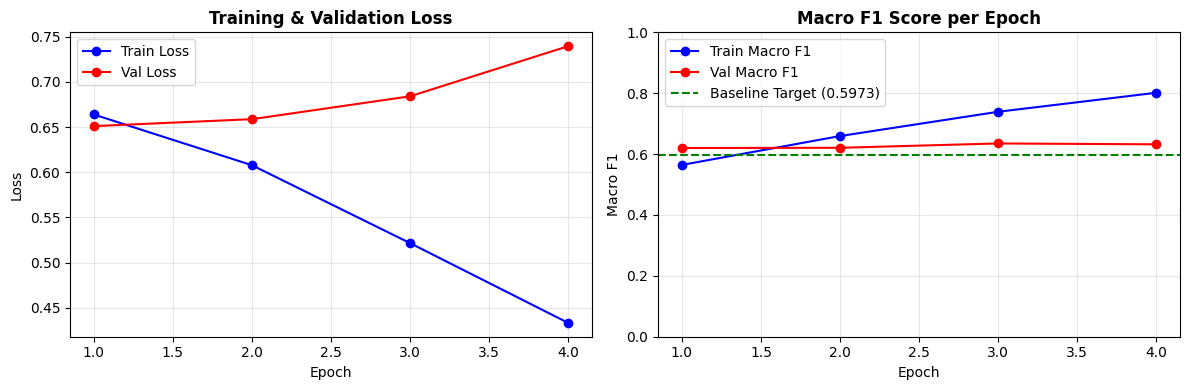

✅ Training curves saved!


In [ ]:
import matplotlib.pyplot as plt
# Training curves plot karo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = [h['epoch'] for h in history]

# Loss curve
ax1.plot(epochs, [h['train_loss'] for h in history],
         'b-o', label='Train Loss')
ax1.plot(epochs, [h['val_loss'] for h in history],
         'r-o', label='Val Loss')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1 curve
ax2.plot(epochs, [h['train_f1'] for h in history],
         'b-o', label='Train Macro F1')
ax2.plot(epochs, [h['val_f1'] for h in history],
         'r-o', label='Val Macro F1')
ax2.axhline(y=0.5973, color='green', linestyle='--',
            label='Baseline Target (0.5973)')
ax2.set_title('Macro F1 Score per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Fake-News-Detection/results/distilbert_training_curves.png',
    dpi=150
)
plt.show()
print("✅ Training curves saved!")

In [ ]:
from transformers import DistilBertForSequenceClassification
from sklearn.metrics import classification_report
import json

# Best model reload karo
best_model = DistilBertForSequenceClassification.from_pretrained(
    SAVE_PATH + 'distilbert_best/'
).to(device)

# Test set evaluate karo
test_loss, test_f1, test_acc, test_preds, test_labels = evaluate(
    best_model, test_loader, device
)

print("=" * 60)
print("   🏆 DISTILBERT — FINAL TEST SET RESULTS")
print("=" * 60)
print(f"   Accuracy   : {test_acc:.4f}")
print(f"   Macro F1   : {test_f1:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=['Fake', 'Real']
))

# RQ1 comparison
print("=" * 60)
print("   📊 RQ1 ANSWER — BASELINE vs DISTILBERT")
print("=" * 60)
baseline_f1   = 0.5973
distilbert_f1 = test_f1
diff = distilbert_f1 - baseline_f1

print(f"   Logistic Regression (Week 2) : {baseline_f1:.4f}")
print(f"   DistilBERT          (Week 3) : {distilbert_f1:.4f}")
print(f"   Difference                   : {diff:+.4f}")

if distilbert_f1 > baseline_f1:
    print(f"\n   ✅ RQ1 ANSWER: DistilBERT is BETTER by {diff:.4f}!")
else:
    print(f"\n   ❌ RQ1 ANSWER: DistilBERT did NOT improve baseline!")

# Save results
results = {
    'model'       : 'DistilBERT',
    'accuracy'    : round(test_acc, 4),
    'macro_f1'    : round(test_f1, 4),
    'baseline_f1' : baseline_f1,
    'improvement' : round(diff, 4)
}
with open(SAVE_PATH + '../results/distilbert_test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✅ Results saved to results/distilbert_test_results.json")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   🏆 DISTILBERT — FINAL TEST SET RESULTS
   Accuracy   : 0.6448
   Macro F1   : 0.6313

              precision    recall  f1-score   support

        Fake       0.61      0.52      0.56       553
        Real       0.67      0.74      0.70       714

    accuracy                           0.64      1267
   macro avg       0.64      0.63      0.63      1267
weighted avg       0.64      0.64      0.64      1267

   📊 RQ1 ANSWER — BASELINE vs DISTILBERT
   Logistic Regression (Week 2) : 0.5973
   DistilBERT          (Week 3) : 0.6313
   Difference                   : +0.0340

   ✅ RQ1 ANSWER: DistilBERT is BETTER by 0.0340!

✅ Results saved to results/distilbert_test_results.json


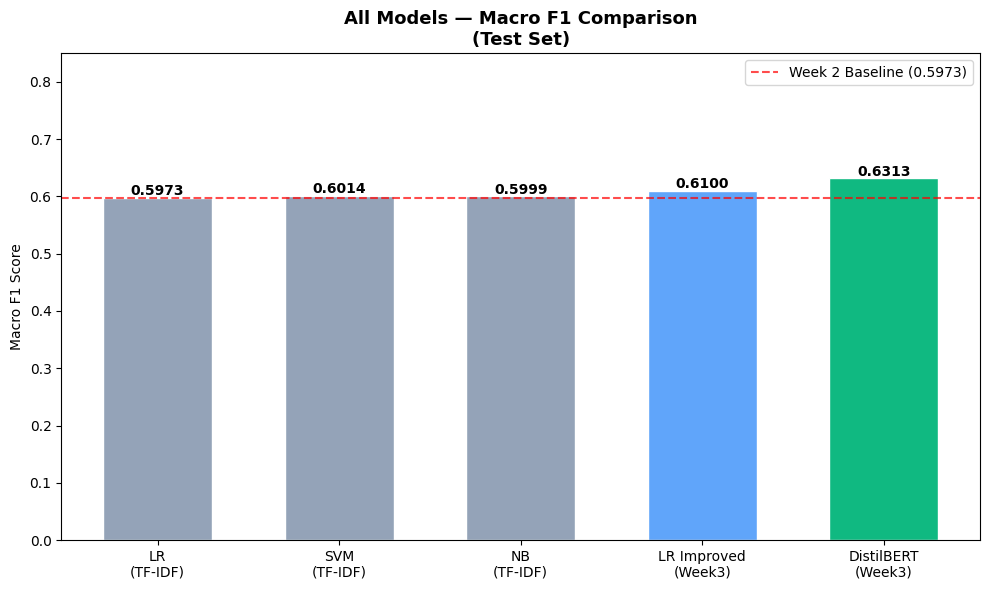

✅ Final comparison chart saved!


In [ ]:
models = ['LR\n(TF-IDF)', 'SVM\n(TF-IDF)', 'NB\n(TF-IDF)',
          'LR Improved\n(Week3)', 'DistilBERT\n(Week3)']

# Apne actual numbers yahan daalo
f1_scores = [0.5973, 0.6014, 0.5999,
             0.61,    # Week 3 improved LR ka score
             test_f1]

colors = ['#94A3B8', '#94A3B8', '#94A3B8',
          '#60A5FA', '#10B981']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color=colors,
               edgecolor='white', width=0.6)

for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=10)

plt.axhline(y=0.5973, color='red', linestyle='--',
            alpha=0.7, label='Week 2 Baseline (0.5973)')
plt.title('All Models — Macro F1 Comparison\n'
          '(Test Set)', fontweight='bold', fontsize=13)
plt.ylabel('Macro F1 Score')
plt.ylim(0, 0.85)
plt.legend()
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Fake-News-Detection/results/week3_final_comparison.png',
    dpi=150
)
plt.show()
print("✅ Final comparison chart saved!")